# Expert evaluation — PCT projection results

Visualises outputs from `src/08_test_experts.py` across the three evaluation methods.

| Method | Name | What it measures |
|--------|------|------------------|
| 1 | Representativeness | PCT projection of generated responses to political statements |
| 2 | Inverse steerability | Resistance to adversarial counter-persona prompts |
| 3 | Consistency | NLL-selected answers to OpinionQA survey questions |

**Inputs:** `data/experts/test-outputs/`  
**Experts:** four LoRA adapters trained on `data/experts/final-experts/`

In [8]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

BASE = Path("../data/experts/test-outputs")

# Condition order
CONDITIONS = [
    "base",
    "econ_left_authoritarian",
    "econ_left_libertarian",
    "econ_right_authoritarian",
    "econ_right_libertarian",
]
EXPERTS = CONDITIONS[1:]  # the four trained adapters

# Visual identity — matches quadrant colours used in the other notebooks
COND_COLOR = {
    "base":                     "#888888",
    "econ_left_authoritarian":  "#9dc5e2",
    "econ_left_libertarian":    "#aee8bf",
    "econ_right_authoritarian": "#e17a7a",
    "econ_right_libertarian":   "#fbf09e",
}
COND_SHORT = {
    "base":                     "Base",
    "econ_left_authoritarian":  "Left-Auth",
    "econ_left_libertarian":    "Left-Lib",
    "econ_right_authoritarian": "Right-Auth",
    "econ_right_libertarian":   "Right-Lib",
}
# Target compass quadrant for each expert (for annotation)
COND_TARGET_COMPASS = {
    "econ_left_authoritarian":  (-1, +1),  # left, auth
    "econ_left_libertarian":    (-1, -1),  # left, lib
    "econ_right_authoritarian": (+1, +1),  # right, auth
    "econ_right_libertarian":   (+1, -1),  # right, lib
}
print("Setup complete.")

Setup complete.


In [9]:
def read_jsonl(path):
    if not Path(path).exists():
        return []
    return [json.loads(l) for l in open(path)]

run_cfg    = json.load(open(BASE / "run_config.json"))
m1_summary = json.load(open(BASE / "method1_summary.json"))
m2_summary = json.load(open(BASE / "method2_summary.json"))   # list
m3_summary = json.load(open(BASE / "method3_summary.json"))
combined   = json.load(open(BASE / "combined_summary.json"))

df_m1 = pd.DataFrame(read_jsonl(BASE / "method1_representativeness.jsonl"))
df_m2 = pd.DataFrame(read_jsonl(BASE / "method2_inverse_steerability.jsonl"))
df_m3 = pd.DataFrame(read_jsonl(BASE / "method3_consistency.jsonl"))

df_m2_summary = pd.DataFrame(m2_summary)
df_m3_topic   = pd.DataFrame(m3_summary["by_expert_topic"])
df_combined   = pd.DataFrame(combined["experts"])

print(f"Method 1 records : {len(df_m1):,}")
print(f"Method 2 records : {len(df_m2):,}")
print(f"Method 3 records : {len(df_m3):,}")
print(f"Warnings         : {combined['warnings']}")

Method 1 records : 200
Method 2 records : 320
Method 3 records : 1,500
Warnings         : []


## Run configuration

In [10]:
print(f"Model            : {run_cfg['model_name']}")
print(f"Projection layer : {run_cfg['projection_layer']}")
print(f"dtype / device   : {run_cfg['dtype']} / {run_cfg['device']}")
print(f"Methods run      : {run_cfg['run_methods']}")
print(f"Limit            : {run_cfg.get('limit', 'None (full)')}")
gen = run_cfg["generation"]
print(f"Generation       : max_new_tokens={gen['max_new_tokens']}  "
      f"do_sample={gen['do_sample']}  temperature={gen['temperature']}")
print()
print("Conditions:")
for c in run_cfg["conditions"]:
    adapter = c['adapter_path'] or '—'
    print(f"  {c['name']:<30s}  {adapter}")

Model            : mistralai/Mistral-7B-v0.1
Projection layer : 16
dtype / device   : bfloat16 / cuda
Methods run      : ['method1', 'method2', 'method3']
Limit            : None
Generation       : max_new_tokens=120  do_sample=False  temperature=0.0

Conditions:
  base                            —
  econ_left_authoritarian         data/experts/final-experts/left_auth
  econ_left_libertarian           data/experts/final-experts/left_lib
  econ_right_authoritarian        data/experts/final-experts/right_auth
  econ_right_libertarian          data/experts/final-experts/right_lib


---
# Method 1 — Representativeness

Each condition generates a free-form response to 40 held-out PCT statements.
The concatenated (statement + response) is projected into PCT space via hidden-state cosine similarity against the economic and social steering vectors.

**Key question:** does each expert's centroid land in its target quadrant?

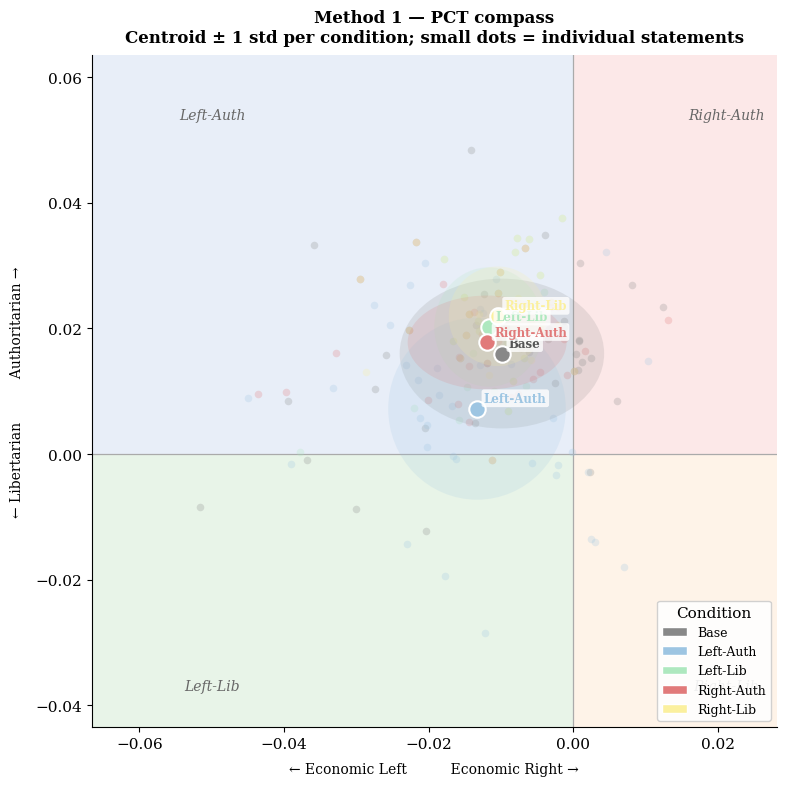

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

# --- axis range: driven by data, include origin
e_all = df_m1["pct_economic"].values
s_all = df_m1["pct_social"].values
pad   = 0.015
xlim  = (min(e_all.min(), 0) - pad, max(e_all.max(), 0) + pad)
ylim  = (min(s_all.min(), 0) - pad, max(s_all.max(), 0) + pad)

x0, x1 = xlim; y0, y1 = ylim

# quadrant shading
ax.add_patch(mpatches.Rectangle((0,  0),  x1,  y1, fc="#fce8e8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((x0, 0), -x0,  y1, fc="#e8eef8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((x0, y0),-x0, -y0, fc="#e8f4e8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((0,  y0),  x1, -y0, fc="#fef3e8", ec="none", zorder=0))
ax.axhline(0, color="#aaa", lw=0.9, zorder=1)
ax.axvline(0, color="#aaa", lw=0.9, zorder=1)

# individual statement points (jittered alpha)
for cond in CONDITIONS:
    sub = df_m1[df_m1["expert"] == cond]
    ax.scatter(sub["pct_economic"], sub["pct_social"],
               color=COND_COLOR[cond], alpha=0.25, s=30,
               linewidths=0, zorder=2)

# centroids + 1-std ellipses
for cond in CONDITIONS:
    sub = df_m1[df_m1["expert"] == cond]
    me  = sub["pct_economic"].mean()
    ms  = sub["pct_social"].mean()
    se  = sub["pct_economic"].std()
    ss  = sub["pct_social"].std()
    ax.add_patch(Ellipse((me, ms), 2*se, 2*ss,
                         fc=COND_COLOR[cond], alpha=0.18, ec="none", zorder=3))
    ax.scatter(me, ms, color=COND_COLOR[cond], s=140, edgecolors="white",
               linewidths=1.5, zorder=5)
    ax.annotate(COND_SHORT[cond], xy=(me, ms), xytext=(5, 5),
                textcoords="offset points", fontsize=8.5, fontweight="bold",
                color=COND_COLOR[cond] if cond != "base" else "#555",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
                zorder=6)

# compass corner labels
kw = dict(fontsize=10, color="#666", va="center", ha="center", style="italic")
ax.text(x1*0.75, y1*0.85, "Right-Auth", **kw)
ax.text(x0*0.75, y1*0.85, "Left-Auth",  **kw)
ax.text(x0*0.75, y0*0.85, "Left-Lib",   **kw)
ax.text(x1*0.75, y0*0.85, "Right-Lib",  **kw)

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel("← Economic Left          Economic Right →", fontsize=10, labelpad=8)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=10, labelpad=8)
ax.set_title("Method 1 — PCT compass\nCentroid ± 1 std per condition; small dots = individual statements",
             fontsize=12, fontweight="bold", pad=10)

legend_handles = [
    mpatches.Patch(fc=COND_COLOR[c], ec="white", label=COND_SHORT[c])
    for c in CONDITIONS
]
ax.legend(handles=legend_handles, title="Condition", loc="lower right",
          fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

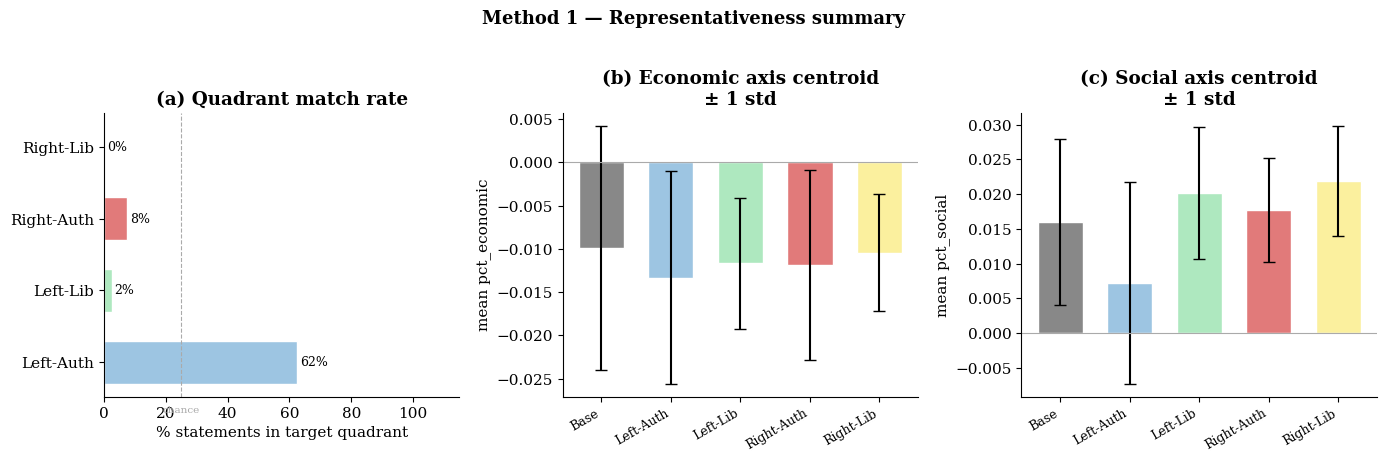

In [12]:
# Match rate and per-axis centroid breakdown
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- (a) Quadrant match rate
ax = axes[0]
match_rates = [
    m1_summary[c].get("quadrant_match_rate") or 0.0
    for c in EXPERTS
]
colors = [COND_COLOR[c] for c in EXPERTS]
labels = [COND_SHORT[c] for c in EXPERTS]
bars = ax.barh(labels, [r * 100 for r in match_rates],
               color=colors, edgecolor="white", height=0.6)
for bar, r in zip(bars, match_rates):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{r*100:.0f}%", va="center", fontsize=9)
ax.axvline(25, color="#aaa", lw=0.8, ls="--")  # chance level
ax.set_xlim(0, 115)
ax.set_xlabel("% statements in target quadrant")
ax.set_title("(a) Quadrant match rate", fontweight="bold")
ax.text(25, -0.7, "chance", fontsize=7.5, color="#aaa", ha="center")

# --- (b) Mean PCT economic axis by condition
ax = axes[1]
econ_means = [m1_summary[c]["mean_pct_economic"] for c in CONDITIONS]
econ_stds  = [m1_summary[c]["std_pct_economic"]  for c in CONDITIONS]
x = np.arange(len(CONDITIONS))
ax.bar(x, econ_means, color=[COND_COLOR[c] for c in CONDITIONS],
       edgecolor="white", yerr=econ_stds, capsize=4, width=0.65)
ax.axhline(0, color="#aaa", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([COND_SHORT[c] for c in CONDITIONS], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("mean pct_economic")
ax.set_title("(b) Economic axis centroid\n± 1 std", fontweight="bold")

# --- (c) Mean PCT social axis by condition
ax = axes[2]
soc_means = [m1_summary[c]["mean_pct_social"] for c in CONDITIONS]
soc_stds  = [m1_summary[c]["std_pct_social"]  for c in CONDITIONS]
ax.bar(x, soc_means, color=[COND_COLOR[c] for c in CONDITIONS],
       edgecolor="white", yerr=soc_stds, capsize=4, width=0.65)
ax.axhline(0, color="#aaa", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([COND_SHORT[c] for c in CONDITIONS], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("mean pct_social")
ax.set_title("(c) Social axis centroid\n± 1 std", fontweight="bold")

plt.suptitle("Method 1 — Representativeness summary", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

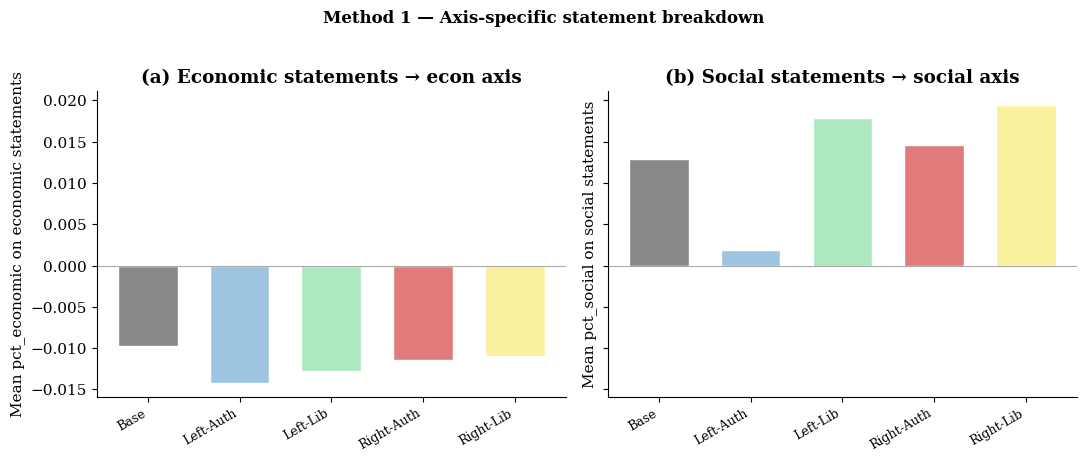

In [13]:
# Economic vs social statement axis breakdown
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

econ_stmt_means = [m1_summary[c].get("economic_statement_mean_pct_economic", float("nan")) for c in CONDITIONS]
soc_stmt_means  = [m1_summary[c].get("social_statement_mean_pct_social",     float("nan")) for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
for ax, vals, label in zip(
    axes,
    [econ_stmt_means, soc_stmt_means],
    ["Mean pct_economic on economic statements",
     "Mean pct_social on social statements"],
):
    bars = ax.bar(x, vals, color=[COND_COLOR[c] for c in CONDITIONS],
                  edgecolor="white", width=0.65)
    ax.axhline(0, color="#aaa", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([COND_SHORT[c] for c in CONDITIONS], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(label)

axes[0].set_title("(a) Economic statements → econ axis", fontweight="bold")
axes[1].set_title("(b) Social statements → social axis",  fontweight="bold")
plt.suptitle("Method 1 — Axis-specific statement breakdown",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
# Method 2 — Inverse steerability

An adversarial counter-persona prompt is prepended to each statement.  
For each trained expert the **designated adversary** is the persona from the diagonally opposite quadrant.  
The base model runs all four personas (used as the shift reference).

**Key metrics:**
- **Shift magnitude** — Euclidean distance in PCT space between Method-1 and Method-2 projections
- **Resistance** = `base_shift − expert_shift` (positive = expert resists better than base)
- **Flip rate** — % of statements where the adversary pushed the projection into a different quadrant

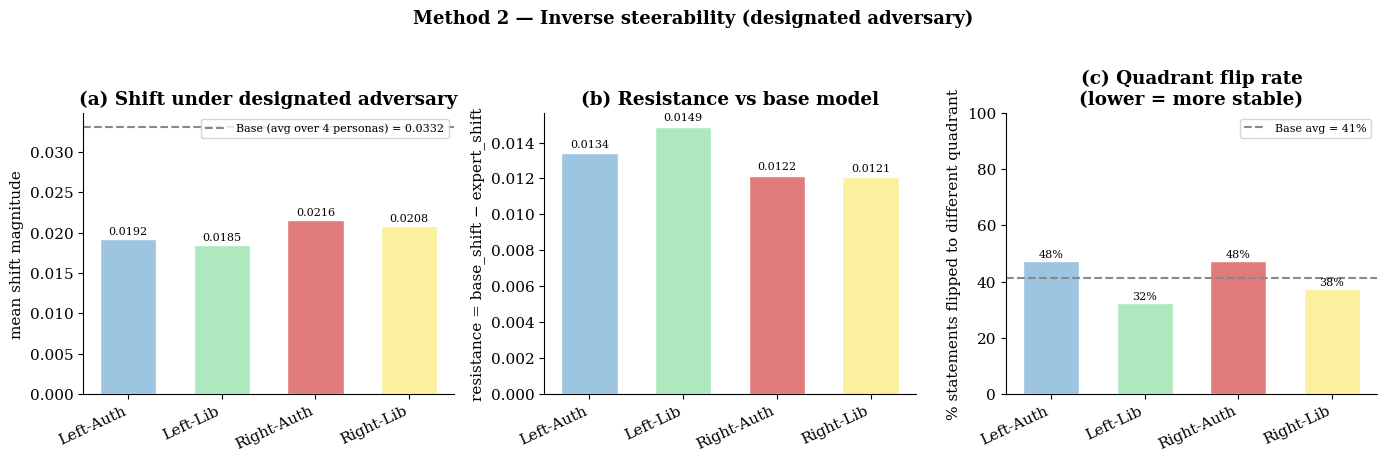

In [14]:
# Designated adversary shift: expert vs base baseline
desig = df_m2_summary[df_m2_summary["is_designated_adversary"]].set_index("expert")
base_rows = df_m2_summary[df_m2_summary["expert"] == "base"]
base_mean_shift = base_rows["mean_shift_magnitude"].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- (a) Shift magnitude
ax = axes[0]
ax.axhline(base_mean_shift, color="#888", lw=1.5, ls="--", zorder=1,
           label=f"Base (avg over 4 personas) = {base_mean_shift:.4f}")
for i, expert in enumerate(EXPERTS):
    row = desig.loc[expert] if expert in desig.index else None
    val = row["mean_shift_magnitude"] if row is not None else 0
    ax.bar(i, val, color=COND_COLOR[expert], edgecolor="white", width=0.6, zorder=2)
    ax.text(i, val + 0.0003, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(EXPERTS)))
ax.set_xticklabels([COND_SHORT[c] for c in EXPERTS], rotation=25, ha="right")
ax.set_ylabel("mean shift magnitude")
ax.set_title("(a) Shift under designated adversary", fontweight="bold")
ax.legend(fontsize=8)

# --- (b) Resistance vs base  (= base_shift - expert_shift)
ax = axes[1]
for i, expert in enumerate(EXPERTS):
    row = desig.loc[expert] if expert in desig.index else None
    val = row["resistance_vs_base"] if row is not None else 0
    ax.bar(i, val, color=COND_COLOR[expert], edgecolor="white", width=0.6)
    ax.text(i, val + 0.0002, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="#aaa", lw=0.8)
ax.set_xticks(range(len(EXPERTS)))
ax.set_xticklabels([COND_SHORT[c] for c in EXPERTS], rotation=25, ha="right")
ax.set_ylabel("resistance = base_shift − expert_shift")
ax.set_title("(b) Resistance vs base model", fontweight="bold")

# --- (c) Quadrant flip rate
ax = axes[2]
for i, expert in enumerate(EXPERTS):
    row = desig.loc[expert] if expert in desig.index else None
    val = (row["quadrant_flip_rate"] or 0) * 100 if row is not None else 0
    ax.bar(i, val, color=COND_COLOR[expert], edgecolor="white", width=0.6)
    ax.text(i, val + 0.5, f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

base_flip = base_rows["quadrant_flip_rate"].mean() * 100
ax.axhline(base_flip, color="#888", lw=1.5, ls="--",
           label=f"Base avg = {base_flip:.0f}%")
ax.set_ylim(0, 100)
ax.set_xticks(range(len(EXPERTS)))
ax.set_xticklabels([COND_SHORT[c] for c in EXPERTS], rotation=25, ha="right")
ax.set_ylabel("% statements flipped to different quadrant")
ax.set_title("(c) Quadrant flip rate\n(lower = more stable)", fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle("Method 2 — Inverse steerability (designated adversary)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

TypeError: tuple indices must be integers or slices, not str

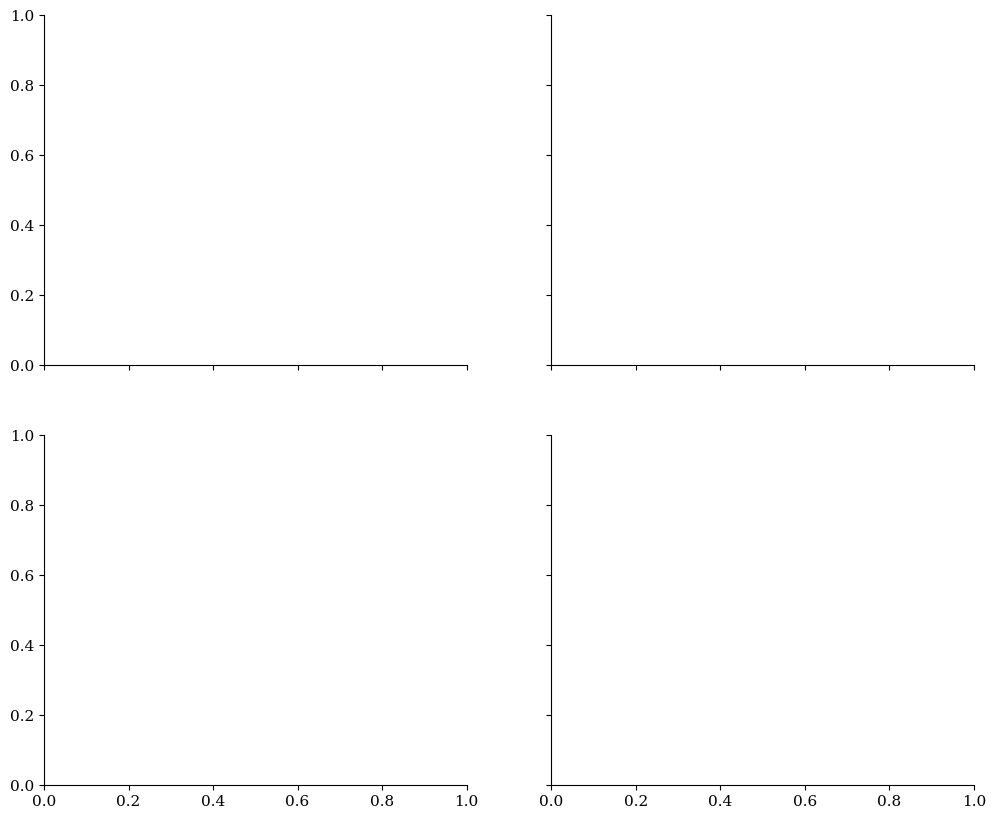

In [15]:
# Arrow plot: base centroid → expert centroid under each expert's designated adversary
# Compare with base model under the same persona
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Base centroids by persona
base_by_persona = (
    df_m2_summary[df_m2_summary["expert"] == "base"]
    .set_index("persona_id")[["mean_pct_economic", "mean_pct_social"]]
)

# M1 centroids
m1_econ = {c: m1_summary[c]["mean_pct_economic"] for c in CONDITIONS}
m1_soc  = {c: m1_summary[c]["mean_pct_social"]   for c in CONDITIONS}

e_vals = [v["mean_pct_economic"] for v in df_m2_summary.itertuples()]
s_vals = [v["mean_pct_social"]   for v in df_m2_summary.itertuples()]
all_e  = list(m1_econ.values()) + [r["mean_pct_economic"] for r in m2_summary]
all_s  = list(m1_soc.values())  + [r["mean_pct_social"]   for r in m2_summary]
pad    = 0.005
xlim   = (min(all_e) - pad, max(all_e) + pad)
ylim   = (min(all_s) - pad, max(all_s) + pad)

persona_for_expert = {
    row["expert"]: row["persona_id"]
    for row in m2_summary
    if row["is_designated_adversary"]
}

for ax, expert in zip(axes.flat, EXPERTS):
    x0e, x1e = xlim; y0e, y1e = ylim
    ax.add_patch(mpatches.Rectangle((0, 0), x1e, y1e,  fc="#fce8e8", ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((x0e,0),-x0e,y1e,  fc="#e8eef8", ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((x0e,y0e),-x0e,-y0e,fc="#e8f4e8",ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((0, y0e), x1e,-y0e, fc="#fef3e8", ec="none", zorder=0))
    ax.axhline(0, color="#aaa", lw=0.7, zorder=1)
    ax.axvline(0, color="#aaa", lw=0.7, zorder=1)

    persona = persona_for_expert.get(expert)
    if not persona:
        ax.set_title(f"{COND_SHORT[expert]} — no adversary found", fontweight="bold")
        continue

    # M1 centroid for this expert
    m1e = m1_econ[expert]; m1s = m1_soc[expert]
    # M2 centroid under designated adversary
    adv_row = df_m2_summary[
        (df_m2_summary["expert"] == expert) &
        (df_m2_summary["persona_id"] == persona)
    ].iloc[0]
    m2e = adv_row["mean_pct_economic"]; m2s = adv_row["mean_pct_social"]

    # Base M1 centroid and M2 under same persona
    base_m1e = m1_econ["base"]; base_m1s = m1_soc["base"]
    base_adv = base_by_persona.loc[persona] if persona in base_by_persona.index else None

    # Plot base arrow (grey)
    if base_adv is not None:
        ax.annotate("", xy=(base_adv["mean_pct_economic"], base_adv["mean_pct_social"]),
                    xytext=(base_m1e, base_m1s),
                    arrowprops=dict(arrowstyle="->", color="#999", lw=1.4), zorder=3)
        ax.scatter(base_m1e, base_m1s, color="#999", s=80, zorder=4, label="Base M1")
        ax.scatter(base_adv["mean_pct_economic"], base_adv["mean_pct_social"],
                   color="#999", marker="X", s=90, zorder=4, label="Base M2")

    # Expert arrow (coloured)
    ax.annotate("", xy=(m2e, m2s), xytext=(m1e, m1s),
                arrowprops=dict(arrowstyle="->", color=COND_COLOR[expert], lw=2.0), zorder=5)
    ax.scatter(m1e, m1s, color=COND_COLOR[expert], s=100, edgecolors="white",
               linewidths=1.2, zorder=6, label=f"{COND_SHORT[expert]} M1")
    ax.scatter(m2e, m2s, color=COND_COLOR[expert], marker="X", s=110,
               edgecolors="white", linewidths=1.2, zorder=6, label=f"{COND_SHORT[expert]} M2")

    adv_label = adv_row.get("persona_label", persona)
    ax.set_title(f"{COND_SHORT[expert]}\nAdversary: {adv_label}",
                 fontweight="bold", fontsize=10)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(fontsize=7.5, loc="upper left")

for ax in axes[-1]:
    ax.set_xlabel("Economic axis")
for ax in axes[:, 0]:
    ax.set_ylabel("Social axis")

plt.suptitle("Method 2 — Shift under designated adversary\n"
             "Circle = M1 centroid, X = M2 centroid (after persona). Grey = base.",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
# Method 3 — Consistency

For each of 300 OpinionQA survey questions the model selects the answer option with the lowest average NLL.  
The (question + selected answer) is then projected into PCT space.

**Key questions:**
- Does each expert's PCT position match its target quadrant more often than chance?
- Is there topic-level differentiation between experts?

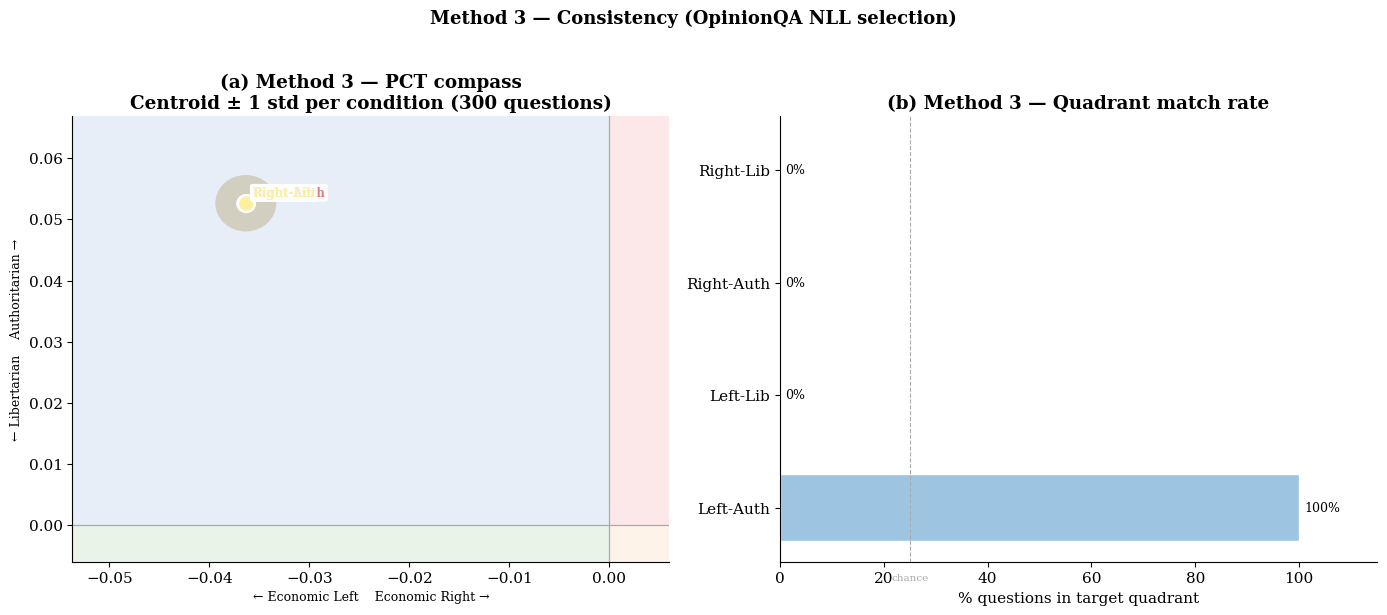

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) PCT compass — method 3 centroids
ax = axes[0]

e_all3 = df_m3["pct_economic"].values
s_all3 = df_m3["pct_social"].values
pad3   = 0.006
xlim3  = (min(e_all3.min(), 0) - pad3, max(e_all3.max(), 0) + pad3)
ylim3  = (min(s_all3.min(), 0) - pad3, max(s_all3.max(), 0) + pad3)
x0e, x1e = xlim3; y0e, y1e = ylim3

ax.add_patch(mpatches.Rectangle((0, 0),   x1e,  y1e,  fc="#fce8e8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((x0e, 0),-x0e,  y1e,  fc="#e8eef8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((x0e,y0e),-x0e,-y0e,  fc="#e8f4e8", ec="none", zorder=0))
ax.add_patch(mpatches.Rectangle((0,  y0e), x1e, -y0e, fc="#fef3e8", ec="none", zorder=0))
ax.axhline(0, color="#aaa", lw=0.9, zorder=1)
ax.axvline(0, color="#aaa", lw=0.9, zorder=1)

for cond in CONDITIONS:
    sub = df_m3[df_m3["expert"] == cond]
    me  = sub["pct_economic"].mean()
    ms  = sub["pct_social"].mean()
    se  = sub["pct_economic"].std()
    ss  = sub["pct_social"].std()
    ax.add_patch(Ellipse((me, ms), 2*se, 2*ss,
                         fc=COND_COLOR[cond], alpha=0.18, ec="none", zorder=3))
    ax.scatter(me, ms, color=COND_COLOR[cond], s=140, edgecolors="white",
               linewidths=1.5, zorder=5)
    ax.annotate(COND_SHORT[cond], xy=(me, ms), xytext=(5, 5),
                textcoords="offset points", fontsize=8.5, fontweight="bold",
                color=COND_COLOR[cond] if cond != "base" else "#555",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
                zorder=6)

ax.set_xlim(xlim3); ax.set_ylim(ylim3)
ax.set_xlabel("← Economic Left    Economic Right →", fontsize=9)
ax.set_ylabel("← Libertarian    Authoritarian →",   fontsize=9)
ax.set_title("(a) Method 3 — PCT compass\nCentroid ± 1 std per condition (300 questions)",
             fontweight="bold")

# --- (b) Match rate
ax = axes[1]
match3 = [m3_summary["by_expert"][c].get("quadrant_match_rate") or 0.0 for c in EXPERTS]
labels = [COND_SHORT[c] for c in EXPERTS]
colors = [COND_COLOR[c] for c in EXPERTS]
bars = ax.barh(labels, [r * 100 for r in match3], color=colors, edgecolor="white", height=0.6)
for bar, r in zip(bars, match3):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{r*100:.0f}%", va="center", fontsize=9)
ax.axvline(25, color="#aaa", lw=0.8, ls="--")
ax.set_xlim(0, 115)
ax.set_xlabel("% questions in target quadrant")
ax.set_title("(b) Method 3 — Quadrant match rate", fontweight="bold")
ax.text(25, -0.65, "chance", fontsize=7.5, color="#aaa", ha="center")

plt.suptitle("Method 3 — Consistency (OpinionQA NLL selection)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

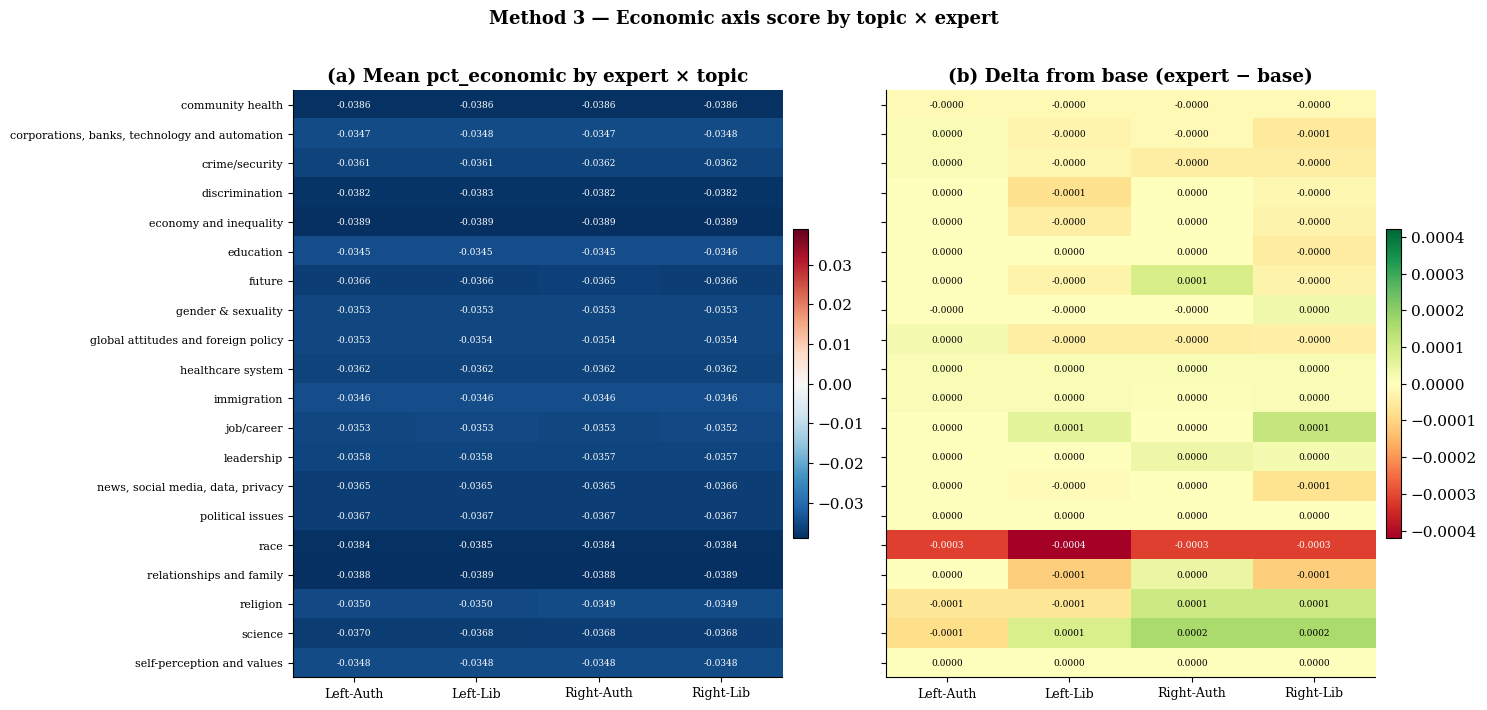

In [17]:
import matplotlib.colors as mcolors

# --- Heatmap: mean pct_economic by expert × topic (delta from base)
topics_sorted = sorted(df_m3_topic["coarse_topic"].unique())

# Build matrix: rows = topics, cols = experts
base_econ_by_topic = (
    df_m3_topic[df_m3_topic["expert"] == "base"]
    .set_index("coarse_topic")["mean_pct_economic"]
)

mat_raw   = np.zeros((len(topics_sorted), len(EXPERTS)))
mat_delta = np.zeros((len(topics_sorted), len(EXPERTS)))

for j, expert in enumerate(EXPERTS):
    sub = df_m3_topic[df_m3_topic["expert"] == expert].set_index("coarse_topic")
    for i, topic in enumerate(topics_sorted):
        val = sub["mean_pct_economic"].get(topic, float("nan"))
        mat_raw[i, j] = val
        base_val = base_econ_by_topic.get(topic, float("nan"))
        mat_delta[i, j] = val - base_val if not np.isnan(val) else float("nan")

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

short_labels = [COND_SHORT[c] for c in EXPERTS]

for ax, mat, title, cmap, center in zip(
    axes,
    [mat_raw, mat_delta],
    ["(a) Mean pct_economic by expert × topic",
     "(b) Delta from base (expert − base)"],
    ["RdBu_r", "RdYlGn"],
    [True, True],
):
    vmax = np.nanmax(np.abs(mat))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")
    for i in range(len(topics_sorted)):
        for j in range(len(EXPERTS)):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=6.5,
                        color="white" if abs(v) > vmax * 0.55 else "black")
    ax.set_xticks(range(len(EXPERTS)))
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_yticks(range(len(topics_sorted)))
    ax.set_yticklabels(topics_sorted, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(title, fontweight="bold")

plt.suptitle("Method 3 — Economic axis score by topic × expert",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

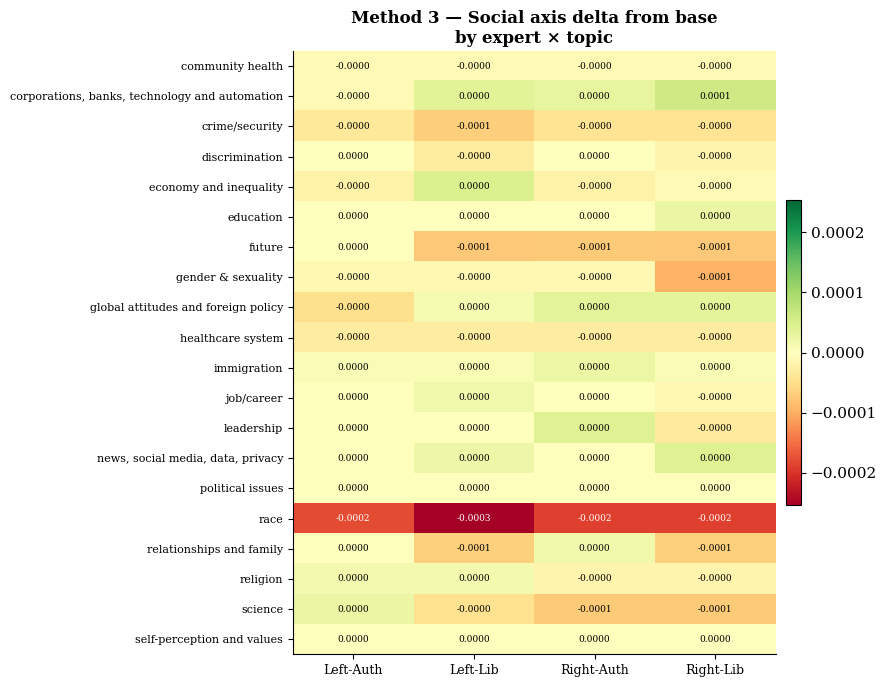

In [18]:
# Same heatmap for social axis
base_soc_by_topic = (
    df_m3_topic[df_m3_topic["expert"] == "base"]
    .set_index("coarse_topic")["mean_pct_social"]
)

mat_soc_delta = np.zeros((len(topics_sorted), len(EXPERTS)))
for j, expert in enumerate(EXPERTS):
    sub = df_m3_topic[df_m3_topic["expert"] == expert].set_index("coarse_topic")
    for i, topic in enumerate(topics_sorted):
        val      = sub["mean_pct_social"].get(topic, float("nan"))
        base_val = base_soc_by_topic.get(topic, float("nan"))
        mat_soc_delta[i, j] = val - base_val if not np.isnan(val) else float("nan")

fig, ax = plt.subplots(figsize=(9, 7))
vmax = np.nanmax(np.abs(mat_soc_delta))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(mat_soc_delta, cmap="RdYlGn", norm=norm, aspect="auto")
for i in range(len(topics_sorted)):
    for j in range(len(EXPERTS)):
        v = mat_soc_delta[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > vmax * 0.55 else "black")
ax.set_xticks(range(len(EXPERTS)))
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_yticks(range(len(topics_sorted)))
ax.set_yticklabels(topics_sorted, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
ax.set_title("Method 3 — Social axis delta from base\nby expert × topic",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---
# Combined summary

Cross-method overview: for each trained expert, the three key metrics side by side.

In [19]:
rows = []
for row in combined["experts"]:
    if row["expert"] == "base":
        continue
    rows.append({
        "Expert":            COND_SHORT[row["expert"]],
        "Target quadrant":   row["target_quadrant"],
        "M1 centroid":       row["method1_centroid_quadrant"],
        "M1 match %":        f"{(row['method1_quadrant_match_rate'] or 0)*100:.0f}%",
        "M2 adv shift":      f"{row['method2_designated_mean_shift']:.4f}" if row['method2_designated_mean_shift'] else "—",
        "M2 resistance":     f"{row['method2_resistance_vs_base']:.4f}"    if row['method2_resistance_vs_base']    else "—",
        "M2 flip %":         f"{(row['method2_designated_flip_rate'] or 0)*100:.0f}%",
        "M3 centroid":       row["method3_centroid_quadrant"],
        "M3 match %":        f"{(row['method3_quadrant_match_rate'] or 0)*100:.0f}%",
    })

df_table = pd.DataFrame(rows).set_index("Expert")
print(df_table.to_string())

                     Target quadrant              M1 centroid M1 match % M2 adv shift M2 resistance M2 flip %              M3 centroid M3 match %
Expert                                                                                                                                           
Left-Auth    econ_left_authoritarian  econ_left_authoritarian        62%       0.0192        0.0134       48%  econ_left_authoritarian       100%
Left-Lib       econ_left_libertarian  econ_left_authoritarian         2%       0.0185        0.0149       32%  econ_left_authoritarian         0%
Right-Auth  econ_right_authoritarian  econ_left_authoritarian         8%       0.0216        0.0122       48%  econ_left_authoritarian         0%
Right-Lib     econ_right_libertarian  econ_left_authoritarian         0%       0.0208        0.0121       38%  econ_left_authoritarian         0%


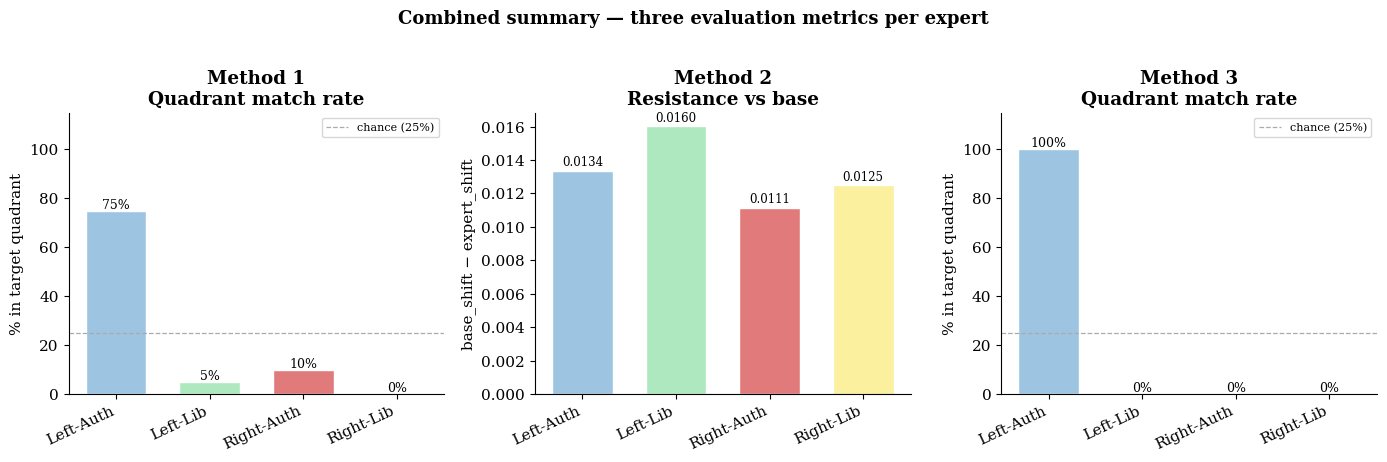

In [13]:
# Side-by-side bar chart: 3 metrics per expert
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

x = np.arange(len(EXPERTS))
colors = [COND_COLOR[c] for c in EXPERTS]
labels = [COND_SHORT[c] for c in EXPERTS]

# M1 match rate
ax = axes[0]
vals = [(df_combined[df_combined["expert"] == e]["method1_quadrant_match_rate"].iloc[0] or 0) * 100
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(25, color="#aaa", lw=0.9, ls="--", label="chance (25%)")
for xi, v in zip(x, vals):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 115); ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("% in target quadrant")
ax.set_title("Method 1\nQuadrant match rate", fontweight="bold")
ax.legend(fontsize=8)

# M2 resistance
ax = axes[1]
vals = [(df_combined[df_combined["expert"] == e]["method2_resistance_vs_base"].iloc[0] or 0)
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(0, color="#aaa", lw=0.8)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.0003, f"{v:.4f}", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("base_shift − expert_shift")
ax.set_title("Method 2\nResistance vs base", fontweight="bold")

# M3 match rate
ax = axes[2]
vals = [(df_combined[df_combined["expert"] == e]["method3_quadrant_match_rate"].iloc[0] or 0) * 100
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(25, color="#aaa", lw=0.9, ls="--", label="chance (25%)")
for xi, v in zip(x, vals):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 115); ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("% in target quadrant")
ax.set_title("Method 3\nQuadrant match rate", fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle("Combined summary — three evaluation metrics per expert",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

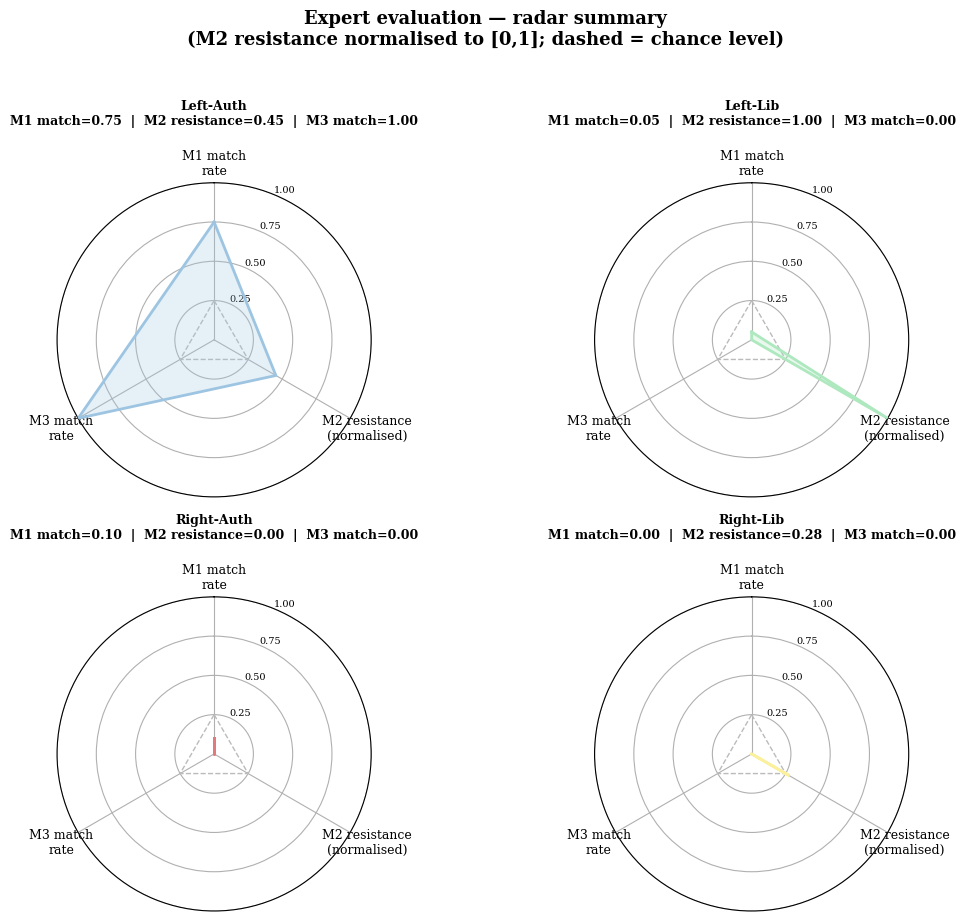

In [14]:
# Radar / spider chart — 3 normalised metrics per expert
# Metrics (all in [0, 1]): M1 match rate, M2 resistance (normalised), M3 match rate
# M2 resistance: normalise to [0, 1] range across experts

resist_vals = np.array([
    float(df_combined[df_combined["expert"] == e]["method2_resistance_vs_base"].iloc[0] or 0)
    for e in EXPERTS
])
resist_min, resist_max = resist_vals.min(), resist_vals.max()
resist_norm = (
    (resist_vals - resist_min) / (resist_max - resist_min)
    if resist_max > resist_min else np.full(len(EXPERTS), 0.5)
)

categories = ["M1 match\nrate", "M2 resistance\n(normalised)", "M3 match\nrate"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                         subplot_kw=dict(polar=True))

for ax, expert, resist in zip(axes.flat, EXPERTS, resist_norm):
    row = df_combined[df_combined["expert"] == expert].iloc[0]
    vals = [
        float(row["method1_quadrant_match_rate"] or 0),
        float(resist),
        float(row["method3_quadrant_match_rate"] or 0),
    ]
    vals_plot = vals + vals[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7)

    # chance line
    ax.plot(angles, [0.25] * (N + 1), color="#bbb", lw=1.0, ls="--")

    ax.plot(angles, vals_plot, color=COND_COLOR[expert], lw=2.0, zorder=3)
    ax.fill(angles, vals_plot, color=COND_COLOR[expert], alpha=0.25, zorder=2)

    metric_str = "  |  ".join(f"{c.split(chr(10))[0]}={v:.2f}" for c, v in zip(categories, vals))
    ax.set_title(f"{COND_SHORT[expert]}\n{metric_str}",
                 fontsize=9, fontweight="bold", pad=18)

plt.suptitle("Expert evaluation — radar summary\n"
             "(M2 resistance normalised to [0,1]; dashed = chance level)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Appendix — Expert dataset split counts

Chunk counts per quadrant and split, read directly from the `06_validate_experts_datasets.py` training log.

In [ ]:
# Expert dataset split counts — from 06_validate_experts_datasets.py log
# Q1 = right_auth · Q2 = left_auth · Q3 = left_lib · Q4 = right_lib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── constants (read from training log) ───────────────────────────────────────
SPLIT_COUNTS = {
    "right_auth": {"train": 1304, "val_indist":  362, "val_source":  921, "val_topic":   256},
    "left_auth":  {"train": 2057, "val_indist":  359, "val_source":  886, "val_topic":   938},
    "left_lib":   {"train": 5118, "val_indist":  929, "val_source": 2086, "val_topic": 13555},
    "right_lib":  {"train": 3669, "val_indist":  629, "val_source": 6018, "val_topic":  7042},
}

QUADRANT_ORDER = ["right_auth", "left_auth", "left_lib", "right_lib"]
QLABELS = {
    "right_auth": "Q1 · right auth",
    "left_auth":  "Q2 · left auth",
    "left_lib":   "Q3 · left lib",
    "right_lib":  "Q4 · right lib",
}
QCOLORS = {
    "right_auth": "#e17a7a",
    "left_auth":  "#9dc5e2",
    "left_lib":   "#aee8bf",
    "right_lib":  "#fbf09e",
}

SPLITS      = ["train", "val_indist", "val_source", "val_topic"]
SLABELS     = ["train", "val\n(in-dist)", "val\n(source)", "val\n(topic)"]

# ── layout ───────────────────────────────────────────────────────────────────
n_q      = len(QUADRANT_ORDER)
n_splits = len(SPLITS)
bar_w    = 0.17
offsets  = np.linspace(-(n_q - 1) / 2, (n_q - 1) / 2, n_q) * bar_w
x        = np.arange(n_splits)

BG   = "#0d0d0d"
GRID = "#2a2a2a"
EDGE = "#1f1f1f"
TEXT = "#e0e0e0"

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i, q in enumerate(QUADRANT_ORDER):
    vals = [SPLIT_COUNTS[q][s] for s in SPLITS]
    bars = ax.bar(
        x + offsets[i], vals, width=bar_w,
        color=QCOLORS[q], label=QLABELS[q],
        alpha=0.88, edgecolor=EDGE, linewidth=0.6,
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=6.5, color=TEXT, fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(SLABELS, fontsize=12, color=TEXT)
ax.set_ylabel("chunk count", fontsize=11, color=TEXT, labelpad=10)
ax.set_title(
    "Expert training dataset — chunk counts per split and quadrant",
    fontsize=13, color=TEXT, fontweight="bold", pad=14,
)

ax.tick_params(axis="both", colors=TEXT, length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.grid(True, color=GRID, linewidth=0.7, linestyle="--")
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

leg = ax.legend(
    loc="upper left", fontsize=10,
    facecolor="#1a1a1a", edgecolor="#444444", labelcolor=TEXT,
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

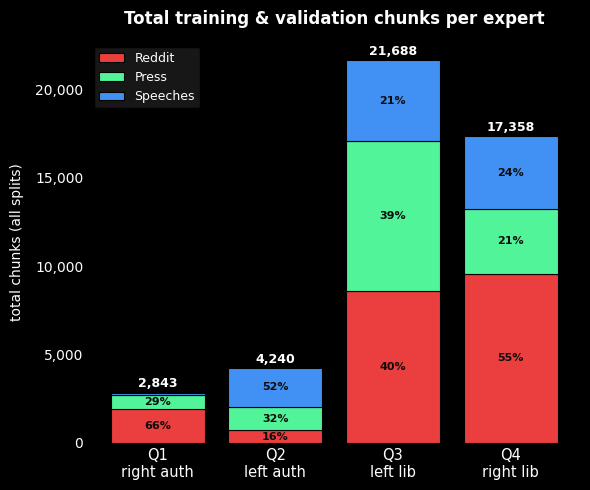

In [7]:
# Stacked bar — total chunks per expert, filled by source group
# Source-group percentages from the training-split distributions in the log.

# ── constants ────────────────────────────────────────────────────────────────
# total = train + val_indist + val_source + val_topic
TOTALS = {
    "right_auth":  2843,   # 1304 + 362 +  921 +  256
    "left_auth":   4240,   # 2057 + 359 +  886 +  938
    "left_lib":   21688,   # 5118 + 929 + 2086 + 13555
    "right_lib":  17358,   # 3669 + 629 + 6018 +  7042
}

# from '=== Train source-group distributions ===' in the log
SOURCE_PCT = {
    "right_auth": {"reddit": 0.664, "press": 0.293, "speeches": 0.043},
    "left_auth":  {"reddit": 0.164, "press": 0.319, "speeches": 0.516},
    "left_lib":   {"reddit": 0.395, "press": 0.392, "speeches": 0.213},
    "right_lib":  {"reddit": 0.552, "press": 0.210, "speeches": 0.238},
}

SOURCES = ["reddit", "press", "speeches"]
SRC_COLORS = {
    "reddit":   "#eb3f3f",
    "press":    "#51f498",
    "speeches": "#4191f4",
}

Q_ORDER  = ["right_auth", "left_auth", "left_lib", "right_lib"]
Q_COLORS = {"right_auth": "#FFFFFF", "left_auth": "#FFFFFF",
            "left_lib": "#FFFFFF", "right_lib": "#FFFFFF"}
QLABELS  = ["Q1\nright auth", "Q2\nleft auth", "Q3\nleft lib", "Q4\nright lib"]

BG, GRID, TEXT = "#000000", "#000000", "#fffcfc"

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i, q in enumerate(Q_ORDER):
    total  = TOTALS[q]
    bottom = 0
    for src in SOURCES:
        h = total * SOURCE_PCT[q][src]
        ax.bar(
            i, h, bottom=bottom,
            color=SRC_COLORS[src],
            label=src.capitalize() if i == 0 else "_nolegend_",
            edgecolor=BG, linewidth=0.8,
        )
        # percentage label inside segment if tall enough
        if h > 400:
            ax.text(
                i, bottom + h / 2,
                f"{SOURCE_PCT[q][src]*100:.0f}%",
                ha="center", va="center",
                fontsize=8, color="#0d0d0d", fontweight="bold",
            )
        bottom += h
    # total on top of bar
    ax.text(
        i, total + 120, f"{total:,}",
        ha="center", va="bottom",
        fontsize=9, color=Q_COLORS[q], fontweight="bold",
    )

ax.set_xticks(range(len(Q_ORDER)))
ax.set_xticklabels(QLABELS, fontsize=10.5, color=TEXT)
ax.set_ylabel("total chunks (all splits)", fontsize=10, color=TEXT, labelpad=8)
ax.set_title(
    "Total training & validation chunks per expert",
    fontsize=12, color=TEXT, fontweight="bold", pad=12,
)

ax.tick_params(axis="both", colors=TEXT, length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color=GRID, linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

ax.legend(
    loc="upper left", fontsize=9,
    facecolor="#1a1a1a", edgecolor="#000000", labelcolor=TEXT,
    framealpha=0.9,
)

plt.tight_layout()
plt.show()